# SynthAudit — Exploratory Analysis

This notebook inspects the synthetic transaction dataset and visualizes the five injected fraud patterns against the legitimate baseline. The goal is to confirm that each pattern is *visible* in the data before attempting to model it.

**Fraud patterns:**
1. `unusual_hour` — Late-night activity (1–4 AM) from high-risk countries
2. `threshold_avoidance` — Amounts just below detection thresholds ($499, $999, $4999)
3. `new_merchant_spike` — Large amounts from unknown merchants
4. `velocity_burst` — Clusters of transactions within minutes
5. `geo_mismatch` — High-value transactions from high-risk countries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme consistent with the rest of the project
BG = '#0F1117'; ACCENT = '#00E5A0'; DANGER = '#FF4B6E'; NEUTRAL = '#4D9FEC'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': '#2A2D3A', 'axes.labelcolor': '#C8CDD8',
    'xtick.color': '#8B90A0', 'ytick.color': '#8B90A0',
    'text.color': '#E8ECF5', 'grid.color': '#1E2130',
    'grid.linewidth': 0.8, 'font.family': 'monospace',
})

df = pd.read_csv("../data/raw/transactions.csv", parse_dates=["timestamp"])
print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean()*100:.2f}%")
df.head()

Dataset shape: (50000, 11)
Fraud rate: 2.50%


,transaction_id,timestamp,amount,merchant,category,country,hour,day_of_week,is_weekend,is_fraud,fraud_type
0,TXN7754119,2023-01-01 00:52:51,138.79,Shell,gas,CA,0,6,1,0,NaN
1,TXN5331729,2023-01-01 06:10:12,396.48,Comcast,utilities,US,6,6,1,0,NaN
2,TXN6868101,2023-01-01 06:33:45,239.07,Macy's,retail,US,6,6,1,0,NaN
3,TXN2678250,2023-01-01 07:29:43,92.46,Olive Garden,restaurant,US,7,6,1,0,NaN
4,TXN5268802,2023-01-01 07:57:19,84.63,Olive Garden,restaurant,US,7,6,1,0,NaN


## 1. Class balance — legit vs fraud

Legit: 48,750
Fraud: 1,250  (2.50%)


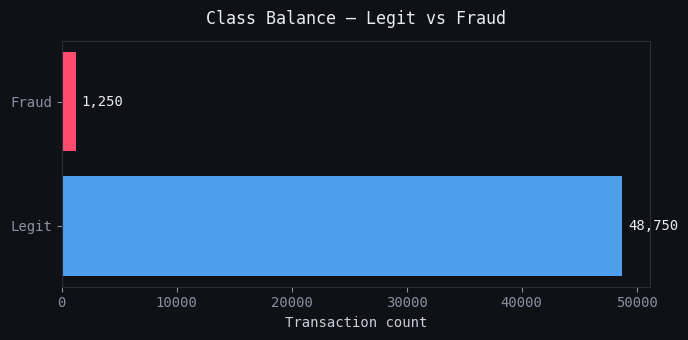

In [2]:
counts = df['is_fraud'].value_counts()
print(f"Legit: {counts[0]:,}")
print(f"Fraud: {counts[1]:,}  ({counts[1]/len(df)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 3.5), facecolor=BG)
ax.barh(['Legit', 'Fraud'], [counts[0], counts[1]], color=[NEUTRAL, DANGER])
ax.set_xlabel('Transaction count')
ax.set_title('Class Balance — Legit vs Fraud', pad=12)
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(v + 500, i, f'{v:,}', va='center', color='#E8ECF5')
plt.tight_layout()
plt.show()

## 2. Fraud pattern distribution

How many transactions each pattern contributed.

fraud_type
threshold_avoidance    250
geo_mismatch           250
unusual_hour           250
new_merchant_spike     250
velocity_burst         250
Name: count, dtype: int64


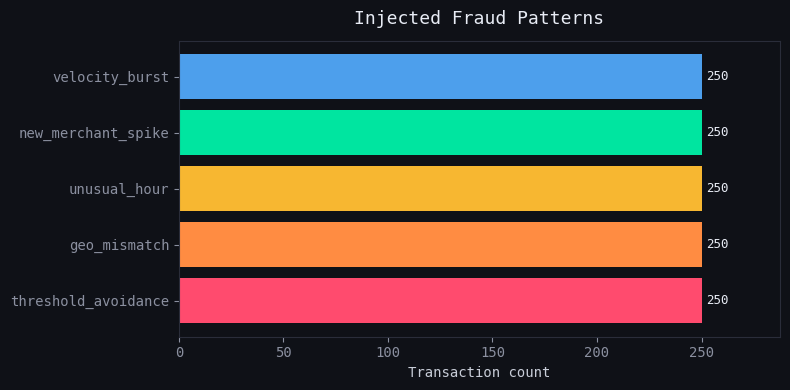

In [3]:
fraud_counts = df[df['is_fraud']==1]['fraud_type'].value_counts()
print(fraud_counts)

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
palette = [DANGER, '#FF8C42', '#F7B731', ACCENT, NEUTRAL]
bars = ax.barh(fraud_counts.index, fraud_counts.values, color=palette)
ax.set_xlabel('Transaction count')
ax.set_title('Injected Fraud Patterns', fontsize=13, pad=12)
for bar, val in zip(bars, fraud_counts.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color='#E8ECF5', fontsize=9)
ax.set_xlim(0, fraud_counts.max() * 1.15)
plt.tight_layout()
plt.show()

## 3. Hourly distribution

Legitimate transactions follow a normal daytime distribution. Fraudulent ones cluster in the early morning hours (1–4 AM) — this is the `unusual_hour` pattern.

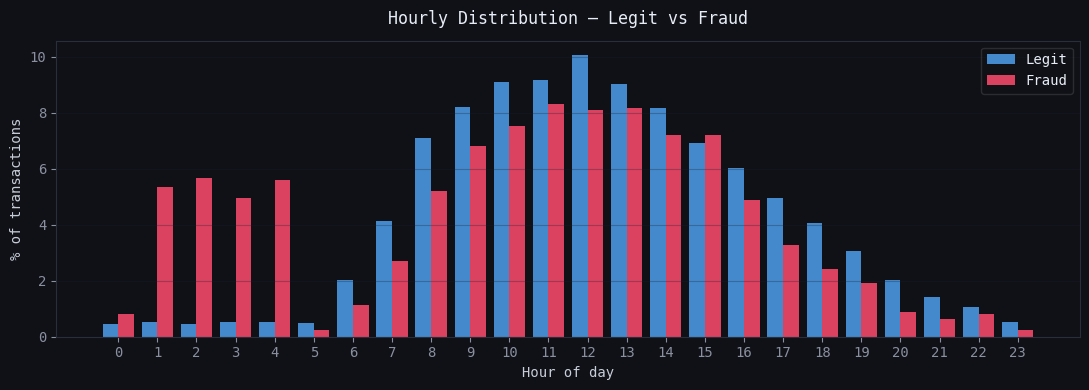

In [4]:
hour_legit = df[df['is_fraud']==0]['hour'].value_counts().sort_index()
hour_fraud = df[df['is_fraud']==1]['hour'].value_counts().sort_index()

# Normalize so both series are comparable
hour_legit_pct = hour_legit / hour_legit.sum() * 100
hour_fraud_pct = hour_fraud / hour_fraud.sum() * 100

fig, ax = plt.subplots(figsize=(11, 4), facecolor=BG)
x = np.arange(24)
width = 0.4
ax.bar(x - width/2, hour_legit_pct.reindex(range(24), fill_value=0),
       width, label='Legit', color=NEUTRAL, alpha=0.85)
ax.bar(x + width/2, hour_fraud_pct.reindex(range(24), fill_value=0),
       width, label='Fraud', color=DANGER, alpha=0.85)
ax.set_xlabel('Hour of day'); ax.set_ylabel('% of transactions')
ax.set_title('Hourly Distribution — Legit vs Fraud', fontsize=12, pad=12)
ax.set_xticks(x)
ax.legend(framealpha=0.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Amount distribution

Legitimate amounts are mostly small. Fraudulent amounts cluster near the detection thresholds ($499, $999, $4999) — this is `threshold_avoidance`.

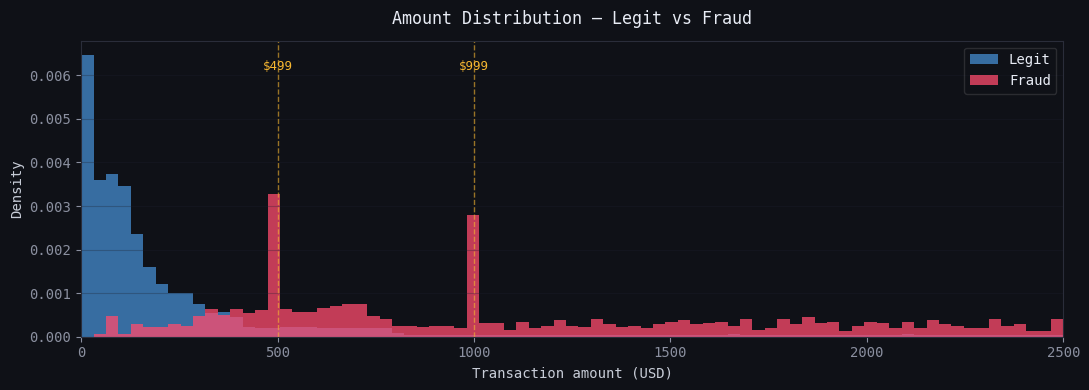

In [5]:
fig, ax = plt.subplots(figsize=(11, 4), facecolor=BG)
bins = np.linspace(0, 2500, 80)
ax.hist(df[df['is_fraud']==0]['amount'], bins=bins, alpha=0.65,
        label='Legit', color=NEUTRAL, density=True)
ax.hist(df[df['is_fraud']==1]['amount'], bins=bins, alpha=0.75,
        label='Fraud', color=DANGER, density=True)
# Threshold markers
for t in [499.99, 999.99]:
    ax.axvline(t, color='#F7B731', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(t, ax.get_ylim()[1]*0.9, f'${int(t)}', color='#F7B731',
            fontsize=9, ha='center')
ax.set_xlabel('Transaction amount (USD)'); ax.set_ylabel('Density')
ax.set_title('Amount Distribution — Legit vs Fraud', fontsize=12, pad=12)
ax.set_xlim(0, 2500)
ax.legend(framealpha=0.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Country breakdown

Fraud is heavily over-represented in high-risk countries. This is the signal behind the `high_risk_country` flag added in feature engineering.

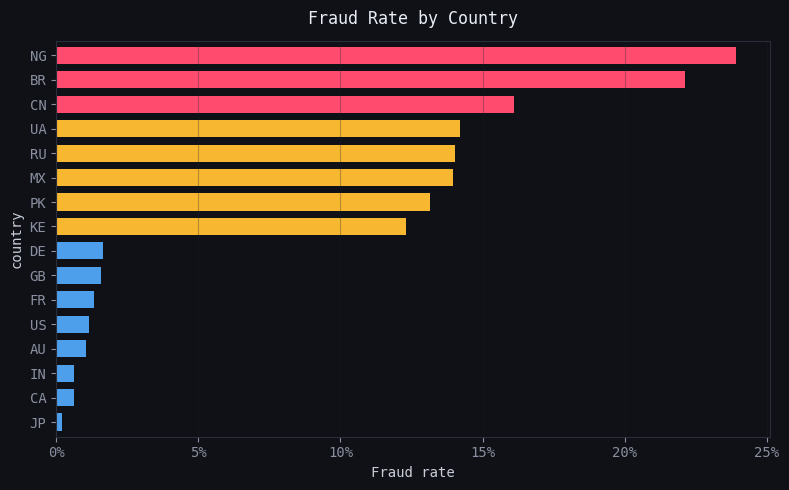

In [6]:
country_total = df['country'].value_counts()
country_fraud = df[df['is_fraud']==1]['country'].value_counts()
fraud_rate_by_country = (country_fraud / country_total).fillna(0).sort_values(ascending=True)
fraud_rate_by_country = fraud_rate_by_country[fraud_rate_by_country > 0]

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
colors = [DANGER if v > 0.15 else '#F7B731' if v > 0.05 else NEUTRAL
          for v in fraud_rate_by_country]
fraud_rate_by_country.plot(kind='barh', color=colors, ax=ax, width=0.7)
ax.set_xlabel('Fraud rate')
ax.set_title('Fraud Rate by Country', fontsize=12, pad=12)
ax.grid(axis='x', alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.show()

## Takeaways

- All five fraud patterns are **visible** in the raw data — each produces a distinct signature.
- The patterns were designed with intent, and the data reflects that intent.
- Next step: train a model to learn these signatures and validate that it generalizes to held-out samples.

→ See `02_fraud_detection_model.ipynb`
